# R-CNN (Region-based Convolutional Neural Network)

---

## 📌 What is R-CNN?

**R-CNN** is an object detection architecture proposed by **Ross Girshick et al. in 2014** (paper: *Rich Feature Hierarchies for Accurate Object Detection and Semantic Segmentation*). Its goal is to **identify and classify multiple objects in an image** by drawing bounding boxes and assigning labels.

---

## 🧠 The Object Detection Problem

Object detection = **Classification + Localization**

Given an image:

* **What objects are present?** (Classification)
* **Where are they located?** (Localization via bounding boxes)

---

## 🔁 Detailed Workflow of R-CNN

### 🧩 Step 1: Region Proposal (Selective Search)

* **Input**: Raw image.
* **Goal**: Propose potential regions (aka Region of Interests - ROIs) that are likely to contain objects.
* **Algorithm**: **Selective Search**.

  * It combines segmentation + hierarchical grouping.
  * Over-segments the image based on color, texture, size, shape.
  * Merges regions based on similarity.
* **Output**: \~2000 region proposals per image, each with bounding box coordinates.


---

### 🧩 Step 2: Region Warping & Preprocessing

* Each proposal is:

  * Cropped from the original image using its bounding box.
  * **Warped to a fixed size** (typically 224×224 pixels) because CNNs require fixed-size inputs.
  * Mean-subtracted (normalization).

---

### 🧩 Step 3: Feature Extraction using a CNN (e.g., AlexNet, VGG16, ResNet50)

* Each resized region is passed through a CNN (usually pretrained on ImageNet).
* Instead of using the final classification layer, we take the **output of the last fully connected layer** (e.g., `fc7` of AlexNet → 4096-dim vector).
* This feature vector captures semantic information of the region.

---

### 🧩 Step 4: Classification using SVM

* For each object class, a **one-vs-rest SVM** is trained.
* Each region proposal’s feature vector is classified using the trained SVMs.
* **Output**: Class label + confidence score.
* Also, a "background" SVM is trained to ignore regions without objects.

---

### 🧩 Step 5: Bounding Box Regression

* SVMs classify what’s inside each region — but not perfectly aligned.
* So, a separate **bounding box regressor** is trained:

  * Input: Feature vector (from CNN).
  * Output: 4 coordinates (`dx`, `dy`, `dw`, `dh`) — offsets to correct the box.
* Uses **Smooth L1 loss** during training to minimize localization error.

---

## 🏗️ R-CNN Architecture Diagram (Text Version)

```
Input Image
   |
[Selective Search]
   |
~2000 region proposals (bounding boxes)
   |
For each box:
   |--> Crop & warp to 224x224
   |--> CNN (e.g., AlexNet)
   |     |
   |     --> Feature Vector (4096-dim)
   |            |
   |            --> SVM classifier (object label)
   |            --> Bounding box regressor (refined coordinates)
```

---

## 🧪 Training R-CNN — A Three-Stage Process

1. **Fine-tune the CNN**:

   * Use region proposals with class labels.
   * Fine-tune the CNN on classification of region proposals.
   * Freeze initial layers if using pretrained weights.

2. **Train SVM classifiers**:

   * Use CNN features of the regions.
   * Train one SVM per class.

3. **Train Bounding Box Regressors**:

   * Learn regression offsets using CNN features to improve localization accuracy.

> ⚠️ Each of these components is trained **independently**, not end-to-end.

---

## 📐 Mathematical Formulations

### 1. **Bounding Box Regression Loss**

Let:

* Ground truth box = $G = (x_g, y_g, w_g, h_g)$
* Proposal box = $P = (x_p, y_p, w_p, h_p)$

We compute target transformations:

$$
t_x = \frac{(x_g - x_p)}{w_p}, \quad
t_y = \frac{(y_g - y_p)}{h_p}, \quad
t_w = \log\left(\frac{w_g}{w_p}\right), \quad
t_h = \log\left(\frac{h_g}{h_p}\right)
$$

The regressor is trained to predict $(t_x, t_y, t_w, t_h)$ using **Smooth L1 Loss**:

$$
\text{SmoothL1}(x) = \begin{cases}
0.5x^2 & \text{if } |x| < 1 \\
|x| - 0.5 & \text{otherwise}
\end{cases}
$$

---

## ⏱️ Performance & Drawbacks

### 🧱 Limitations

| Problem                    | Details                                                                       |
| -------------------------- | ----------------------------------------------------------------------------- |
| **Slow Inference**         | 2000 region proposals processed **independently** through CNN.                |
| **Disk Storage**           | CNN features for all regions are extracted and stored, using huge disk space. |
| **No end-to-end training** | CNN, SVM, and regressor are trained in 3 separate stages.                     |
| **Redundant Computation**  | Overlapping proposals compute features redundantly.                           |

---

## 🧬 Evolution: From R-CNN to Faster Methods

| Model            | Key Improvement                                                             |
| ---------------- | --------------------------------------------------------------------------- |
| **Fast R-CNN**   | Computes CNN features once for the whole image. Uses **RoI Pooling**.       |
| **Faster R-CNN** | Introduces **Region Proposal Network (RPN)** to eliminate Selective Search. |
| **Mask R-CNN**   | Adds **mask segmentation** branch for instance segmentation.                |

---

## 📊 Performance Metrics

* Dataset: **PASCAL VOC 2007**
* R-CNN (AlexNet, fine-tuned): **mAP ≈ 53.3%**
* Before R-CNN (HOG, DPM): **mAP ≈ 30%**

---

## 🧠 Key Takeaways

* R-CNN was **the first to apply deep CNNs to object detection**.
* It showed that **region-based detection** using deep learning is far superior to traditional methods.
* Although inefficient, R-CNN pioneered concepts like:

  * Region-based detection.
  * CNN feature reuse.
  * Bounding box regression.
  * Class-specific detectors.

---

## 📚 Useful References

* Original paper: [R-CNN - Rich Feature Hierarchies](https://arxiv.org/abs/1311.2524)
* Ross Girshick’s blog: [http://rossgirshick.github.io](http://rossgirshick.github.io)
* GitHub implementations: Many are available using PyTorch, TensorFlow, etc.

---

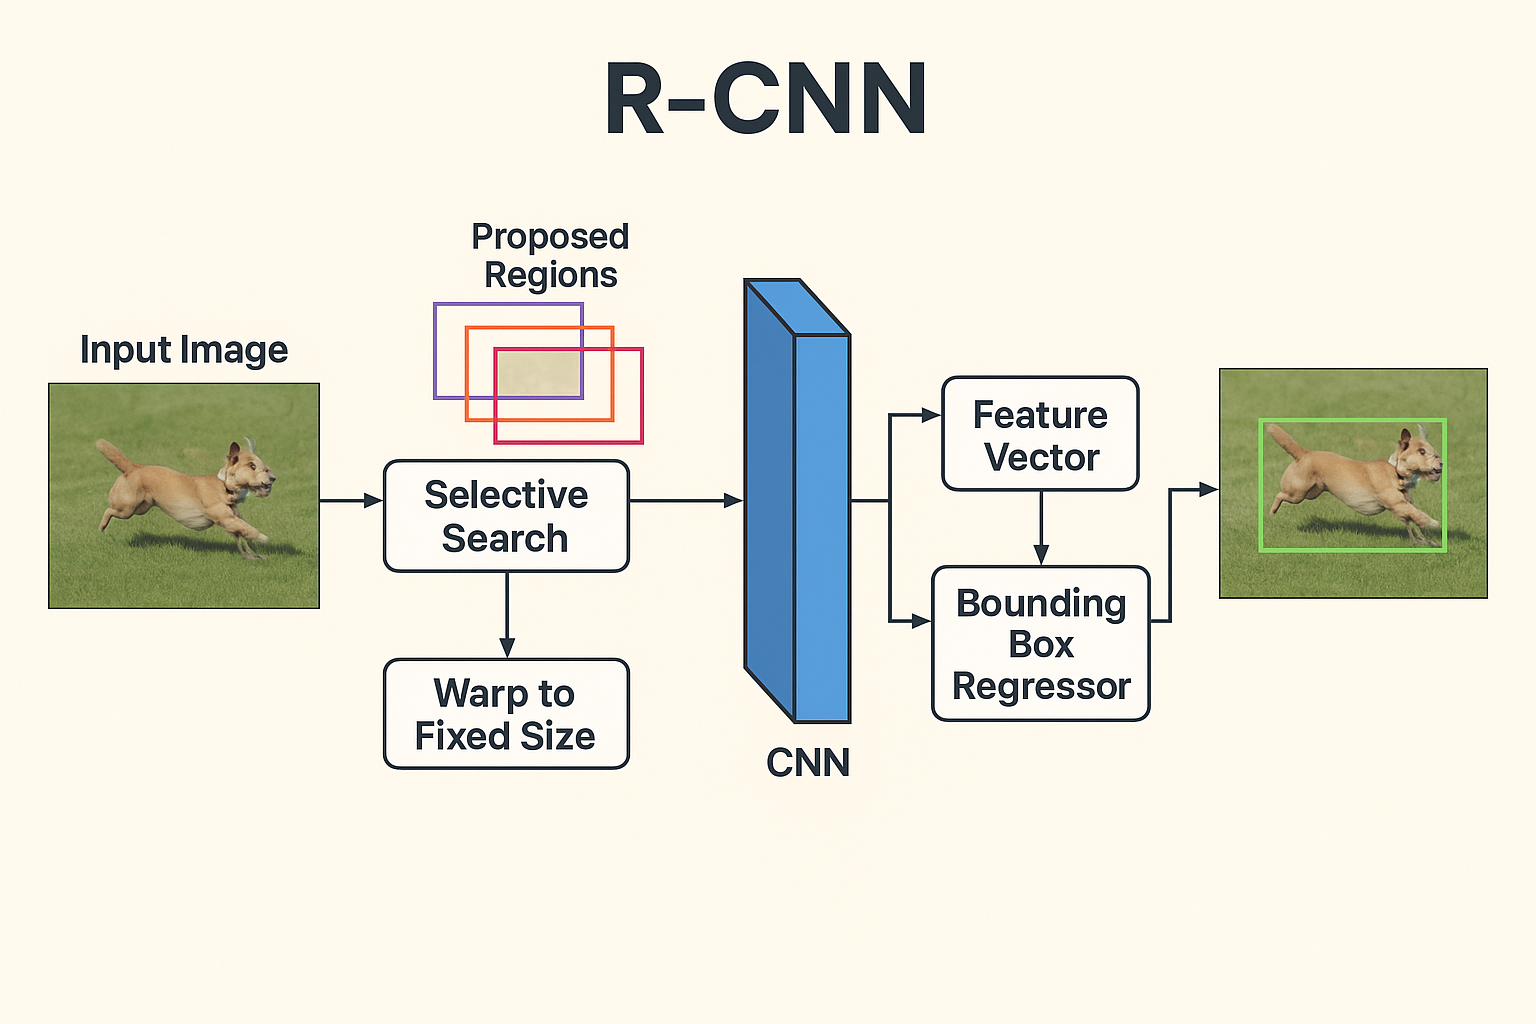

# R-CNN Technique

# Steps in detailed  way

###  1. Extract region proposals from an image. We need to ensure that we extract a high number of proposals to not miss out on any potential object within the image.

###  2. Resize(warp) all the extracted regions to get regions of the same size.

###  3. Pass the resized region proposals through a network. Typically , we pass the resized region proposals through a pretrained model, such as VGG16 or ResNet50, and extrat   the features in a fully connected layer.

###  4. Create data for model training , where the input is features extracted by passing the region proposals through a pretrained model. The outputs are the class corresponding to each region proposal and the offset of the region proposal from the ground truth corresponding to the image.

###  If a region proposal has an iou greater than a specific threshold with the object, we create training data. In this scenario, the region is tasked with predicting both the class of the object it overlaps with the offset of the region proposal related to the ground- truth bounding box that encompasses the object of interest.

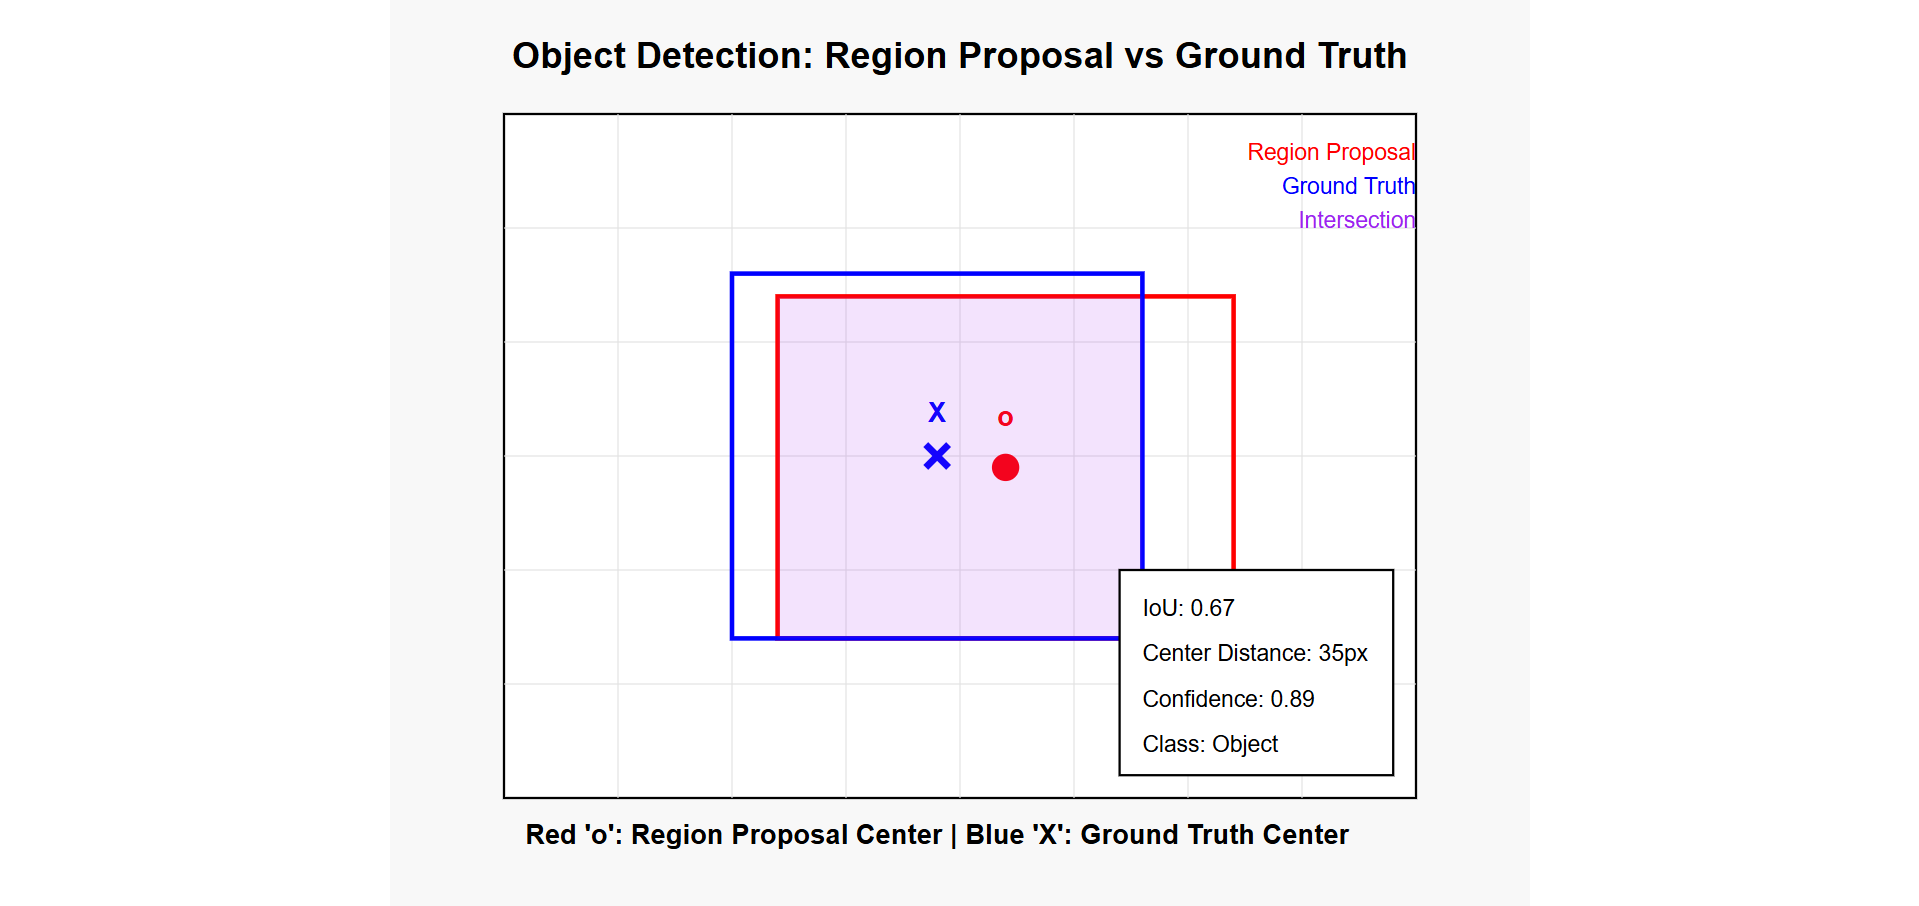



###  In the image showing center of region proposal and ground-truth bounding box , We calculate the offset between the region proposal bounding box and the ground-truth bounding box as the difference between the center coordinates of the two bounding boxes (dx, dy) and the difference between the height and width of the bounding boxes (dw, dh).

###  5. Connect two output heads, one corresponding to the class of image and the other corresponding to the offset of the region proposal with the ground-truth bounding box, to extract the fine bounding box on the object.

###  6. Train the model after writing a custom loss function that minimizes both the object classification error and the bounding-box offset error.

###  here we are minimizing the loss function that is diffferent from original paper to reduce complexity.....

# Downloading the dataset

In [2]:
%pip install -q --upgrade kaggle selectivesearch torch_snippets
from torch_snippets import *
import selectivesearch
import torch

# Authenticate Kaggle API
from google.colab import files
files.upload()  # Upload your kaggle.json

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset WITHOUT version flag
!kaggle datasets download -d sixhky/open-images-bus-trucks

# Verify download and unzip
!ls -lh *.zip
!unzip -qq open-images-bus-trucks.zip

# Import remaining components
from torchvision import transforms, models, datasets
from torchvision.ops import nms

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.7/220.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sixhky/open-images-bus-trucks
License(s): unknown
-rw-r--r-- 1 root root 367M May 28  2020 open-images-bus-trucks.zip
Using device: cuda


In [3]:
IMAGE_ROOT = 'images/images'
DF_RAW = pd.read_csv('/content/df.csv')  # Images with their ground truth labels in CSV format
print(DF_RAW.head())

            ImageID  Source LabelName  Confidence      XMin      XMax  \
0  0000599864fd15b3  xclick       Bus           1  0.343750  0.908750   
1  00006bdb1eb5cd74  xclick     Truck           1  0.276667  0.697500   
2  00006bdb1eb5cd74  xclick     Truck           1  0.702500  0.999167   
3  00010bf498b64bab  xclick       Bus           1  0.156250  0.371250   
4  00013f14dd4e168f  xclick       Bus           1  0.287500  0.999375   

       YMin      YMax  IsOccluded  IsTruncated  ...  IsDepiction  IsInside  \
0  0.156162  0.650047           1            0  ...            0         0   
1  0.141604  0.437343           1            0  ...            0         0   
2  0.204261  0.409774           1            1  ...            0         0   
3  0.269188  0.705228           0            0  ...            0         0   
4  0.194184  0.999062           0            1  ...            0         0   

   XClick1X  XClick2X  XClick3X  XClick4X  XClick1Y  XClick2Y  XClick3Y  \
0  0.421875  0.34

In [7]:
!pip install torch-snippets

# Preparing the dataset

#### 1. Fetching each image and its corresponding class and bounding box values

#### 2. Fetching the region proposals within each image, their corresponding IoU, and the delta by which the region proposal will be corrected with respect to the ground truth.

#### 3. Assigning numeric labels for each class (where we have an additional background class, besides the bus and truck classes, where IoU with the ground-truth bounding box is below a threshold)

#### 4. Resizing each region proposal to a common size in order to pass them to a network

In [4]:
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_snippets import *
import cv2

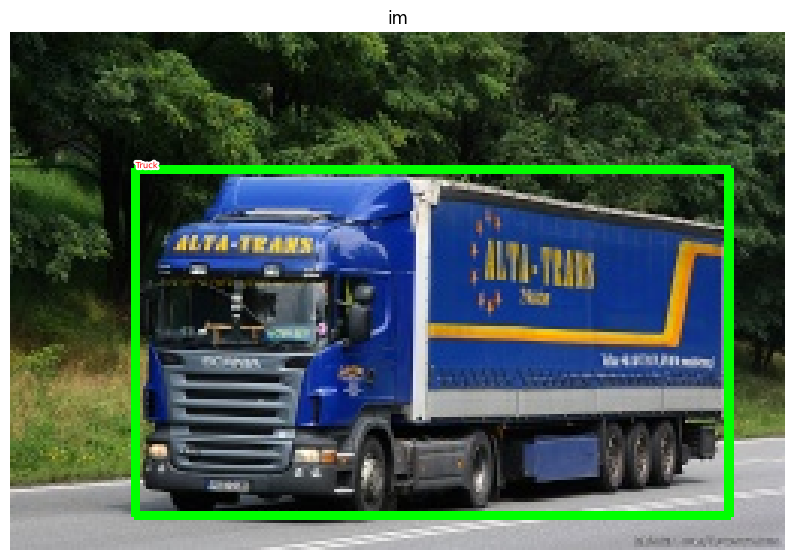

In [5]:
class OpenImages(Dataset):
    def __init__(self, df, image_folder=IMAGE_ROOT):
        self.root = image_folder
        self.df = df
        self.unique_images = df['ImageID'].unique()  # unique image IDs because an image can contain multiple objects and so multiple rows can correpond to the same ImageID value.
    def __len__(self): return len(self.unique_images)
    def __getitem__(self, ix):
        image_id = self.unique_images[ix]
        image_path = f'{self.root}/{image_id}.jpg'
        image = cv2.imread(image_path, 1)[...,::-1] # conver BGR to RGB
        h, w, _ = image.shape
        df = self.df.copy()
        df = df[df['ImageID'] == image_id]
        boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
        boxes = (boxes * np.array([w,h,w,h])).astype(np.uint16).tolist()
        classes = df['LabelName'].values.tolist()
        return image, boxes, classes, image_path
ds = OpenImages(df=DF_RAW)
im, bbs, clss, _ = ds[9]
show(im, bbs=bbs, texts=clss, sz=10)

In [6]:
def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r['rect'] in candidates: continue
        if r['size'] < (0.05*img_area): continue
        if r['size'] > (1*img_area): continue
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
    return candidates

def extract_iou(boxA, boxB, epsilon=1e-5):
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    width = (x2 - x1)
    height = (y2 - y1)
    if (width<0) or (height <0):
        return 0.0
    area_overlap = width * height
    area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    area_combined = area_a + area_b - area_overlap
    iou = area_overlap / (area_combined+epsilon)
    return iou

# Fetching region proposals and the ground truth of offset

In [ ]:
FPATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [], [], [], [], [], []
# FPATHS --> List of image paths
# GTBBS --> List of ground truth bounding boxes
# CLSS --> List of classes for each bounding box
# DELTAS --> List of the delta offset of a bounding box with region proposals
# ROIS --> List of region proposals
# IOUS --> List of IoU values for each region proposal with the ground truth bounding boxes
N = 500
for ix, (im, bbs, labels, fpath) in enumerate(ds):
    if(ix==N):
        break
    H, W, _ = im.shape
    candidates = extract_candidates(im)
    candidates = np.array([(x,y,x+w,y+h) for x,y,w,h in candidates])
    ious, rois, clss, deltas = [], [], [], []
    ious = np.array([[extract_iou(candidate, _bb_) for candidate in candidates] for _bb_ in bbs]).T
    for jx, candidate in enumerate(candidates):
        cx,cy,cX,cY = candidate
        candidate_ious = ious[jx]
        best_iou_at = np.argmax(candidate_ious)
        best_iou = candidate_ious[best_iou_at]
        best_bb = _x,_y,_X,_Y = bbs[best_iou_at]
        if best_iou > 0.3: clss.append(labels[best_iou_at])
        else : clss.append('background')
        delta = np.array([_x-cx, _y-cy, _X-cX, _Y-cY]) / np.array([W,H,W,H])
        deltas.append(delta)
        rois.append(candidate / np.array([W,H,W,H]))
    FPATHS.append(fpath)
    IOUS.append(ious)
    ROIS.append(rois)
    CLSS.append(clss)
    DELTAS.append(deltas)
    GTBBS.append(bbs)
FPATHS = [f'{IMAGE_ROOT}/{stem(f)}.jpg' for f in FPATHS]
FPATHS, GTBBS, CLSS, DELTAS, ROIS = [item for item in [FPATHS, GTBBS, CLSS, DELTAS, ROIS]]

In [8]:
targets = pd.DataFrame(flatten(CLSS), columns=['label'])
label2target = {l:t for t,l in enumerate(targets['label'].unique())}  # background class is 0, bus is 1, truck is 2
target2label = {t:l for l,t in label2target.items()}
background_class = label2target['background']

# Creating the Training Data

#### So far we have fetched data, fetched region proposals across all images, prepared the ground truths of the clas of object present within each regional proposal, and the offset corresponding to each region proposal that has a high overlap(IoU) with the object in the corresponding image.

In [9]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
def preprocess_image(img):
    img = torch.tensor(img).permute(2,0,1)
    img = normalize(img)
    return img.to(device).float()
def decode(_y):
    _, preds = _y.max(-1)
    return preds


In [10]:
class RCNNDataset(Dataset):
    def __init__(self, fpaths, rois, labels, deltas, gtbbs):
        self.fpaths = fpaths
        self.gtbbs = gtbbs
        self.rois = rois
        self.labels = labels
        self.deltas = deltas
    def __len__(self): return len(self.fpaths)
    def __getitem__(self, ix):
        fpath = str(self.fpaths[ix])
        image = cv2.imread(fpath, 1)[...,::-1]
        H, W, _ = image.shape
        sh = np.array([W,H,W,H])
        gtbbs = self.gtbbs[ix]
        rois = self.rois[ix]
        bbs = (np.array(rois)*sh).astype(np.uint16)
        labels = self.labels[ix]
        deltas = self.deltas[ix]
        crops = [image[y:Y,x:X] for (x,y,X,Y) in bbs]
        return image, crops, bbs, labels, deltas, gtbbs, fpath
    def collate_fn(self, batch):
        input, rois, rixs, labels, deltas = [], [], [], [], []
        for ix in range(len(batch)):
            image, crops, image_bbs, image_labels, image_deltas, image_gt_bbs, image_fpath = batch[ix]
            crops = [cv2.resize(crop, (224,224)) for crop in crops]
            crops = [preprocess_image(crop/255.)[None] for crop in crops]
            input.extend(crops)
            labels.extend([label2target[c] for c in image_labels])
            deltas.extend(image_deltas)
        input = torch.cat(input).to(device)
        labels = torch.Tensor(labels).long().to(device)
        deltas = torch.Tensor(deltas).float().to(device)
        return input, labels, deltas


In [11]:
n_train = 9*len(FPATHS)//10  # 90% for training and 10% for testing
train_ds = RCNNDataset(FPATHS[:n_train], ROIS[:n_train], CLSS[:n_train], DELTAS[:n_train], GTBBS[:n_train])
test_ds = RCNNDataset(FPATHS[n_train:], ROIS[n_train:], CLSS[n_train:], DELTAS[n_train:], GTBBS[n_train:])

from torch.utils.data import TensorDataset, DataLoader
train_loader = DataLoader(train_ds, batch_size=2, collate_fn=train_ds.collate_fn, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=2, collate_fn=test_ds.collate_fn, drop_last=True)

In [13]:
vgg_backbone = models.vgg16(pretrained=True)
vgg_backbone.classifier = nn.Sequential()
for param in vgg_backbone.parameters():
    param.requires_grad = False
vgg_backbone.eval().to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# R-CNN network architecture
The following strategy is adopted for R-CNN network architecture

1. Define a VGG backbone.

2. Fetch the features post passing the normalized crop through a pretrained model.

3. Attach a linear layer with sigmoid activation to the VGG backbone to predict the class corresponding to the region proposal.

4. Attach an additional linear layer to predict the four bounding box offsets.

5. Define the loss calculations for each of the two outputs (one to predict class and the other to predict the four bounding box offsets).

6. Train the model that predicts both the class of region proposal and the four bounding box offsets.

In [14]:
class RCNN(nn.Module):
    def __init__(self):
        super().__init__()
        feature_dim = 25088
        self.backbone = vgg_backbone
        self.cls_score = nn.Linear(feature_dim, len(label2target))
        self.bbox = nn.Sequential(
              nn.Linear(feature_dim, 512),
              nn.ReLU(),
              nn.Linear(512, 4),
              nn.Tanh(),
            )
        self.cel = nn.CrossEntropyLoss()
        self.sl1 = nn.L1Loss()
    def forward(self, input):
        feat = self.backbone(input)
        cls_score = self.cls_score(feat)
        bbox = self.bbox(feat)
        return cls_score, bbox
    def calc_loss(self, probs, _deltas, labels, deltas):
        detection_loss = self.cel(probs, labels)
        ixs, = torch.where(labels != 0)  # ignore background class means we don't want to calculate loss for background class
        _deltas = _deltas[ixs]
        deltas = deltas[ixs]
        self.lmb = 10.0 # lambda for regression loss
        if len(ixs) > 0:
            regression_loss = self.sl1(_deltas, deltas)
            return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss.detach()
        else:
            regression_loss = 0
            return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss

In [15]:
def train_batch(inputs, model, optimizer, criterion):
    input, clss, deltas = inputs
    model.train()
    optimizer.zero_grad()
    _clss, _deltas = model(input)
    loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)
    accs = clss == decode(_clss)
    loss.backward()
    optimizer.step()
    return loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()

In [16]:
@torch.no_grad()
def validate_batch(inputs, model, criterion):
    input, clss, deltas = inputs
    with torch.no_grad():
        model.eval()
        _clss,_deltas = model(input)
        loss, loc_loss, regr_loss = criterion(_clss, _deltas, clss, deltas)
        _, _clss = _clss.max(-1)
        accs = clss == _clss
    return _clss, _deltas, loss.detach(), loc_loss, regr_loss, accs.cpu().numpy()

<ipython-input-10-23d19889ad1f>:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  deltas = torch.Tensor(deltas).float().to(device)


Epoch 1/5
Train Loss: 2.5343 | Val Loss: 2.1610
Train Acc: 0.7516 | Val Acc: 0.7920
--------------------------------------------------
Epoch 2/5
Train Loss: 1.6854 | Val Loss: 2.0620
Train Acc: 0.8802 | Val Acc: 0.8069
--------------------------------------------------
Epoch 3/5
Train Loss: 1.3017 | Val Loss: 2.0213
Train Acc: 0.9250 | Val Acc: 0.8069
--------------------------------------------------
Epoch 4/5
Train Loss: 1.1111 | Val Loss: 2.0179
Train Acc: 0.9440 | Val Acc: 0.8115
--------------------------------------------------
Epoch 5/5
Train Loss: 0.9740 | Val Loss: 1.9948
Train Acc: 0.9565 | Val Acc: 0.8099
--------------------------------------------------


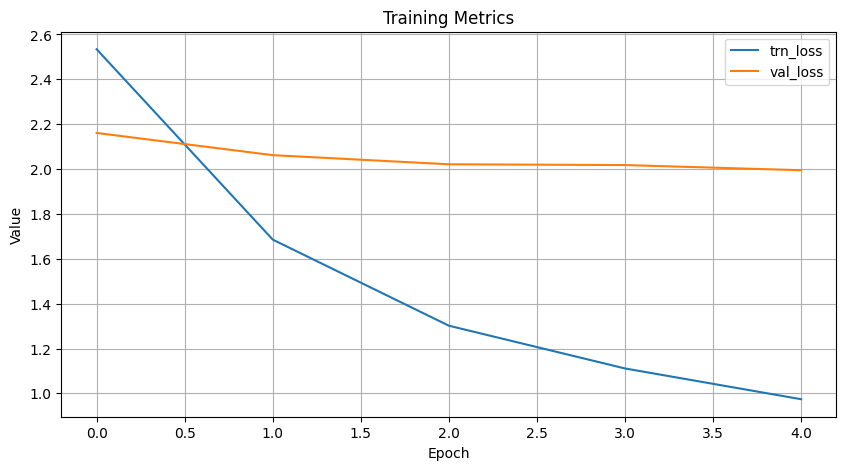

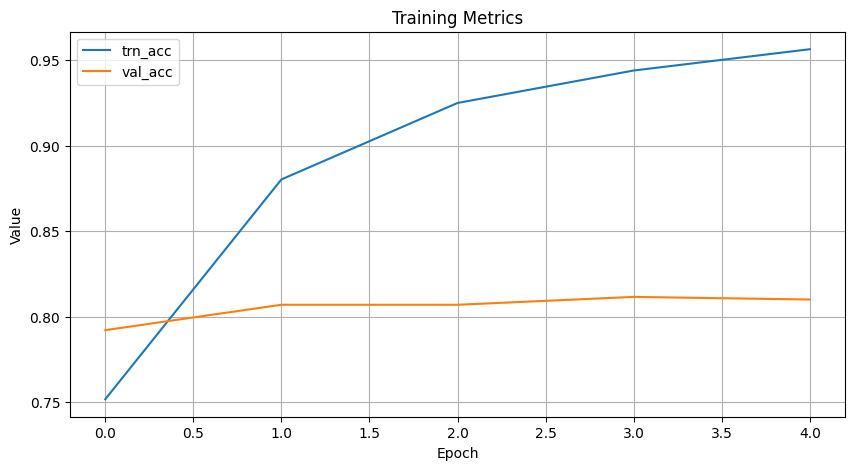

In [18]:
import matplotlib.pyplot as plt

rcnn = RCNN().to(device)
criterion = rcnn.calc_loss
optimizer = optim.SGD(rcnn.parameters(), lr=1e-3)
n_epochs = 5

# Initialize metric tracking
history = {
    'trn_loss': [], 'trn_loc_loss': [], 'trn_regr_loss': [], 'trn_acc': [],
    'val_loss': [], 'val_loc_loss': [], 'val_regr_loss': [], 'val_acc': []
}

class MetricLogger:
    def __init__(self):
        self.reset()

    def reset(self):
        self.loss = 0.0
        self.loc_loss = 0.0
        self.regr_loss = 0.0
        self.acc = 0.0
        self.total = 0

    def update(self, loss, loc_loss, regr_loss, acc, batch_size):
        self.loss += loss * batch_size
        self.loc_loss += loc_loss * batch_size
        self.regr_loss += regr_loss * batch_size
        self.acc += acc * batch_size
        self.total += batch_size

    def get_avg(self):
        return {
            'loss': self.loss / self.total,
            'loc_loss': self.loc_loss / self.total,
            'regr_loss': self.regr_loss / self.total,
            'acc': self.acc / self.total
        }

for epoch in range(n_epochs):
    # Training phase
    train_logger = MetricLogger()
    rcnn.train()
    for inputs in train_loader:
        loss, loc_loss, regr_loss, accs = train_batch(inputs, rcnn, optimizer, criterion)
        batch_size = inputs[0].size(0)
        train_logger.update(loss.item(), loc_loss, regr_loss, accs.mean(), batch_size)

    # Record training metrics
    train_metrics = train_logger.get_avg()
    history['trn_loss'].append(train_metrics['loss'])
    history['trn_loc_loss'].append(train_metrics['loc_loss'])
    history['trn_regr_loss'].append(train_metrics['regr_loss'])
    history['trn_acc'].append(train_metrics['acc'])

    # Validation phase
    val_logger = MetricLogger()
    rcnn.eval()
    with torch.no_grad():
        for inputs in test_loader:
            _clss, _deltas, loss, loc_loss, regr_loss, accs = validate_batch(inputs, rcnn, criterion)
            batch_size = inputs[0].size(0)
            val_logger.update(loss.item(), loc_loss, regr_loss, accs.mean(), batch_size)

    # Record validation metrics
    val_metrics = val_logger.get_avg()
    history['val_loss'].append(val_metrics['loss'])
    history['val_loc_loss'].append(val_metrics['loc_loss'])
    history['val_regr_loss'].append(val_metrics['regr_loss'])
    history['val_acc'].append(val_metrics['acc'])

    # Print epoch summary
    print(f'Epoch {epoch+1}/{n_epochs}')
    print(f'Train Loss: {train_metrics["loss"]:.4f} | Val Loss: {val_metrics["loss"]:.4f}')
    print(f'Train Acc: {train_metrics["acc"]:.4f} | Val Acc: {val_metrics["acc"]:.4f}')
    print('-'*50)

# Plotting function
def plot_metrics(history, metrics):
    plt.figure(figsize=(10, 5))
    for metric in metrics:
        if metric in history:
            plt.plot(history[metric], label=metric)
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Training Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot training and validation losses
plot_metrics(history, ['trn_loss', 'val_loss'])
plot_metrics(history, ['trn_acc', 'val_acc'])

# Predicting on a new image

In [19]:
def test_predictions(filename, show_output=True):
    img = np.array(cv2.imread(filename, 1)[...,::-1])
    candidates = extract_candidates(img)
    candidates = [(x,y,x+w,y+h) for x,y,w,h in candidates]
    input = []
    for candidate in candidates:
        x,y,X,Y = candidate
        crop = cv2.resize(img[y:Y,x:X], (224,224))
        input.append(preprocess_image(crop/255.)[None])
    input = torch.cat(input).to(device)
    with torch.no_grad(): # predicting the class and offset
        rcnn.eval()
        probs, deltas = rcnn(input)
        probs = torch.nn.functional.softmax(probs, -1)
        confs, clss = torch.max(probs, -1)
    candidates = np.array(candidates)  # Extracting out the candidates that do not belong to the background class and sum up the candidates' bounding box with the predicted bounding-box offset values...
    confs, clss, probs, deltas = [tensor.detach().cpu().numpy() for tensor in [confs, clss, probs, deltas]]

    ixs = clss!=background_class
    confs, clss, probs, deltas, candidates = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates]]
    bbs = (candidates + deltas).astype(np.uint16)

    # Using Non-max suppression(nms) to eliminate near-duplicate bounding boxes (pairs of boxes that have an IoU greater than 0.05 are considered duplicates in this case).
    # Among the duplicated boxes, we pick the box with the highest confidence and discard the rest
    ixs = nms(torch.tensor(bbs.astype(np.float32)), torch.tensor(confs), 0.05)
    confs, clss, probs, deltas, candidates, bbs = [tensor[ixs] for tensor in [confs, clss, probs, deltas, candidates, bbs]]
    if len(ixs) == 1:
        confs, clss, probs, deltas, candidates, bbs = [tensor[None] for tensor in [confs, clss, probs, deltas, candidates, bbs]]
    if len(confs) == 0 and not show_output:
        return (0,0,224,224), 'background', 0
    if len(confs) > 0:
        best_pred = np.argmax(confs)
        best_conf = np.max(confs)
        best_bb = bbs[best_pred]
        x,y,X,Y = best_bb
    _, ax = plt.subplots(1, 2, figsize=(20,10))
    show(img, ax=ax[0])
    ax[0].grid(False)
    ax[0].set_title('Original image')
    if len(confs) == 0:
        ax[1].imshow(img)
        ax[1].set_title('No objects')
        plt.show()
        return
    ax[1].set_title(target2label[clss[best_pred]])
    show(img, bbs=bbs.tolist(), texts=[target2label[c] for c in clss.tolist()], ax=ax[1], title='predicted bounding box and class')
    plt.show()
    return (x,y,X,Y),target2label[clss[best_pred]],best_conf

/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


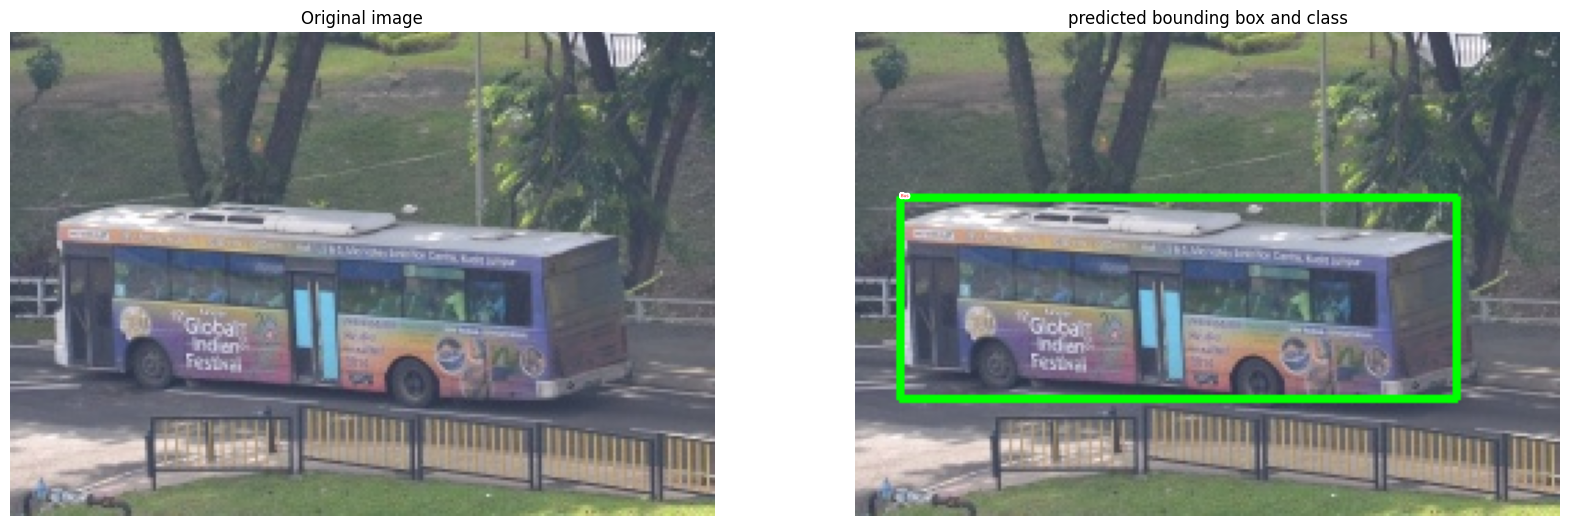

((np.uint16(16), np.uint16(60), np.uint16(218), np.uint16(133)),
 'Bus',
 np.float32(0.9876264))

In [20]:
image, crops, bbs, labels, deltas, gtbbs, fpath = test_ds[7]
test_predictions(fpath)

### Note that it took ~1.5 seconds to generate a prediction for the image

### All of this time is spent in generating region proposals, resizing each region proposal , passing them through a VGG backbone, generating predictions using the defined model.

### The most time spent is in passing each region proposal through the VGG backbone. we will learn around getting around this passing each proposal to VGG problem by using Fast R-CNN architecture based model.